# Aprendizaje Automático
## Práctica 2: Aprendizaje No Supervisado
### Autores
- Ernesto González · 100522276 · 100522276@alumnos.uc3m.es
- David Benito · 100522289 · 100522289@alumnos.uc3m.es
## Introducción

El objetivo de esta práctica es determinar, usando algoritmos de aprendizaje no supervisado, los **tipos de un conjunto de estrellas**.

## 1. Configuración Inicial del entorno
Empezamos por incluir todo lo necesario, clonando el repositorio de GitHub asociado a la práctica.

In [43]:
!rm -rf p2-aprendizaje-automatico-100522276-100522289
!git clone https://github.com/100522289/p2-aprendizaje-automatico-100522276-100522289/

Cloning into 'p2-aprendizaje-automatico-100522276-100522289'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (22/22), done.
Receiving objects: 100% (23/23), 254.95 KiB | 1.32 MiB/s, done.
remote: Total 23 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (5/5), done.


Ahora, disponemos del dataset stars_data.csv, que contiene las características físicas de 240 estrellas que serán agrupadas mediante algoritmos de aprendizaje no supervisado.

## 2. EDA

Primero, comprobamos qué variables contiene el dataset

In [44]:
import pandas as pd
import numpy as np
from sklearn import preprocessing

# Cargar el dataset
file_path = 'p2-aprendizaje-automatico-100522276-100522289/stars_data.csv'
df = pd.read_csv(file_path)

# Descripción personalizada de las variables
print("Descripción de las variables del dataset:")
for col in df.columns:
    dtype = df[col].dtype
    unique_vals = df[col].nunique()
    print(f"- Variable: {col}")
    print(f"  Tipo: {dtype}")
    print(f"  Valores únicos: {unique_vals}")
    print("-" * 30)

# Mostrar las primeras filas
display(df.head())

Descripción de las variables del dataset:
- Variable: Temperature
  Tipo: int64
  Valores únicos: 228
------------------------------
- Variable: L
  Tipo: float64
  Valores únicos: 208
------------------------------
- Variable: R
  Tipo: float64
  Valores únicos: 216
------------------------------
- Variable: A_M
  Tipo: float64
  Valores únicos: 228
------------------------------
- Variable: Color
  Tipo: object
  Valores únicos: 17
------------------------------
- Variable: Spectral_Class
  Tipo: object
  Valores únicos: 7
------------------------------


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [45]:
import pandas as pd

# Recargamos una versión temporal para ver los nombres originales
df_raw = pd.read_csv('p2-aprendizaje-automatico-100522276-100522289/stars_data.csv')
df_raw['Color'] = df_raw['Color'].str.strip().str.lower()

print("Valores originales de 'Color' antes de la codificación:")
print(df_raw['Color'].unique())

print("\nMapping en el DataFrame actual (df):")
# Mostramos la relación entre el color original y el código asignado
mapping = pd.DataFrame({
    'Original': df_raw['Color'],
    'Codificado': df['Color']
}).drop_duplicates().sort_values(by='Codificado')

display(mapping)

Valores originales de 'Color' antes de la codificación:
['red' 'blue white' 'white' 'yellowish white' 'pale yellow orange' 'blue'
 'blue-white' 'whitish' 'yellow-white' 'orange' 'white-yellow' 'yellowish'
 'orange-red']

Mapping en el DataFrame actual (df):


,Original,Codificado
30,blue,Blue
20,blue white,Blue White
26,blue white,Blue white
151,blue-white,Blue-White
31,blue-white,Blue-white
53,orange,Orange
96,orange-red,Orange-Red
29,pale yellow orange,Pale yellow orange
0,red,Red
21,white,White


### 2.1. Codificación Ordinal de Variables Categóricas
Definimos un orden lógico para 'Color' y 'Spectral_Class' basado en la temperatura y energía de las estrellas.

In [46]:
from sklearn.preprocessing import OrdinalEncoder

# Estandarizamos los nombres de los colores en el df
df['Color'] = df['Color'].str.strip().str.lower()

# Definimos el orden jerárquico basado en la lista proporcionada
# Ordenados de menor a mayor energía/temperatura aproximada
color_order = [
    'red',
    'orange',
    'orange-red',
    'pale yellow orange',
    'yellowish',
    'yellow-white',
    'white-yellow',
    'yellowish white',
    'whitish',
    'white',
    'blue-white',
    'blue white',
    'blue'
]

# Orden de Clase Espectral (de menor a mayor energía)
spectral_order = ['M', 'K', 'G', 'F', 'A', 'B', 'O']

# Configuramos el codificador con las categorías específicas
encoder = OrdinalEncoder(categories=[color_order, spectral_order])

# Aplicamos la transformación
df[['Color', 'Spectral_Class']] = encoder.fit_transform(df[['Color', 'Spectral_Class']])

print("Variables codificadas con el orden de colores optimizado.")
display(df.head(100))

Variables codificadas con el orden de colores optimizado.


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,0.0,0.0
1,3042,0.000500,0.1542,16.60,0.0,0.0
2,2600,0.000300,0.1020,18.70,0.0,0.0
3,2800,0.000200,0.1600,16.65,0.0,0.0
4,1939,0.000138,0.1030,20.06,0.0,0.0
...,...,...,...,...,...,...
95,11250,672.000000,6.9800,-2.30,10.0,4.0
96,5112,0.630000,0.8760,4.68,2.0,1.0
97,7720,7.920000,1.3400,2.44,5.0,3.0
98,12098,689.000000,7.0100,0.02,10.0,4.0


## 3. Reducción de dimensionalidad mediante PCA

Con el objetivo de facilitar la visualización de los datos y mejorar la aplicación de los algoritmos de clustering, se realizará una reducción de dimensionalidad mediante PCA (Principal Component Analysis).

Se proyectarán los datos sobre las dos componentes principales, tal y como se indica en el enunciado.

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Escalado previo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA a 2 dimensiones
pca = PCA(n_components=2, random_state=100522289)
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print("Varianza explicada:")
print(pca.explained_variance_ratio_)
print("Varianza total explicada:", sum(pca.explained_variance_ratio_))

df_pca.head()

Varianza explicada:
[0.55458973 0.29762617]
Varianza total explicada: 0.8522158997619902


,PC1,PC2
0,-2.062434,-0.156174
1,-2.081890,-0.174194
2,-2.183226,-0.245640
3,-2.095738,-0.170688
4,-2.267357,-0.283451


A continuación se representa gráficamente la distribución de las estrellas en el nuevo espacio bidimensional generado por PCA.

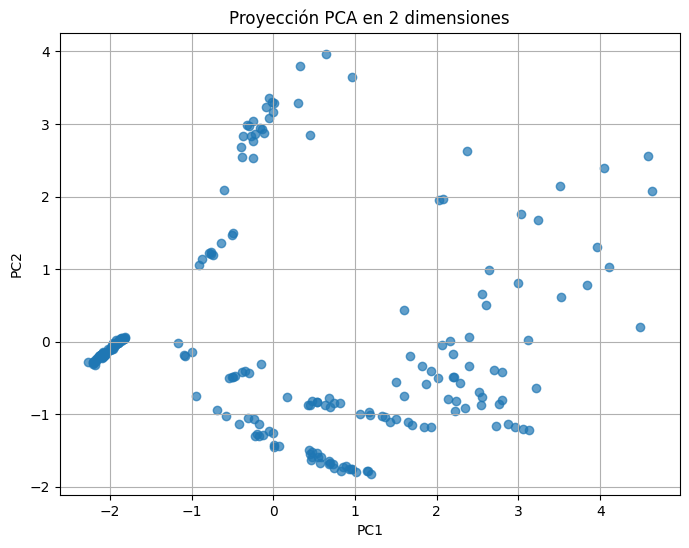

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA en 2 dimensiones")
plt.grid(True)
plt.show()

Las dos primeras componentes principales explican aproximadamente el 85.22% de la varianza total del conjunto de datos.

Esto indica que la reducción a dos dimensiones conserva gran parte de la información original, por lo que resulta adecuada tanto para visualización como para aplicar posteriormente algoritmos de clustering.

Además, en la representación gráfica se observan agrupaciones naturales entre distintas estrellas, lo que sugiere que existen estructuras internas en los datos.

## 4. Clustering mediante K-Means

Se aplicará el algoritmo K-Means probando distintos valores de K para determinar el número óptimo de clusters.

Como métrica de evaluación se utilizará el Silhouette Score, que mide la cohesión interna y separación entre grupos.

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
ks = range(2, 9)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=100522289, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    print(f"K={k} -> Silhouette Score = {score:.4f}")

K=2 -> Silhouette Score = 0.5191
K=3 -> Silhouette Score = 0.5931
K=4 -> Silhouette Score = 0.6276
K=5 -> Silhouette Score = 0.6418
K=6 -> Silhouette Score = 0.6493
K=7 -> Silhouette Score = 0.6365
K=8 -> Silhouette Score = 0.6270


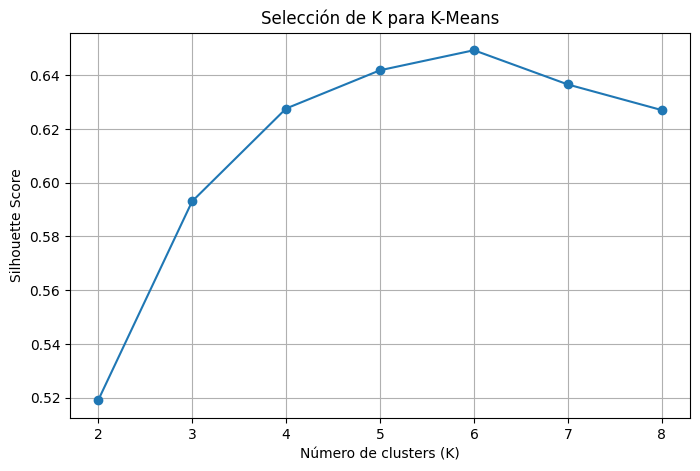

In [50]:
plt.figure(figsize=(8,5))
plt.plot(list(ks), scores, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Selección de K para K-Means")
plt.grid(True)
plt.show()

Se han probado distintos valores de K entre 2 y 8 utilizando como criterio el Silhouette Score.

El mejor resultado se obtiene para **K = 6**, con un valor de **0.6493**, lo que indica una buena separación entre grupos y una adecuada cohesión interna.

Además, este resultado es especialmente interesante, ya que coincide con las seis categorías de estrellas propuestas en la clasificación astronómica del enunciado.

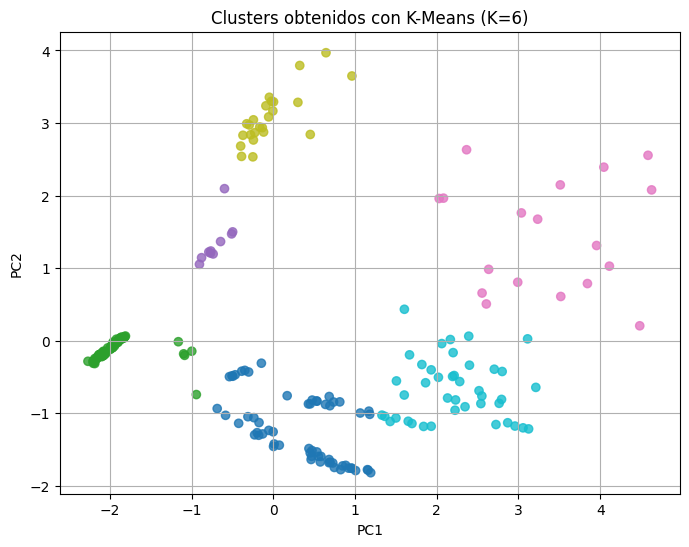

In [51]:
# Modelo final KMeans con K=6
kmeans_final = KMeans(n_clusters=6, random_state=100522289, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_pca)

# Gráfico
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters obtenidos con K-Means (K=6)")
plt.grid(True)
plt.show()

## 5. Clustering jerárquico

Se aplicará ahora clustering jerárquico aglomerativo, utilizando como criterio de enlace el método Ward, ya que suele funcionar especialmente bien con datos continuos y busca minimizar la varianza interna de los grupos.

Además, se representará el dendrograma correspondiente.

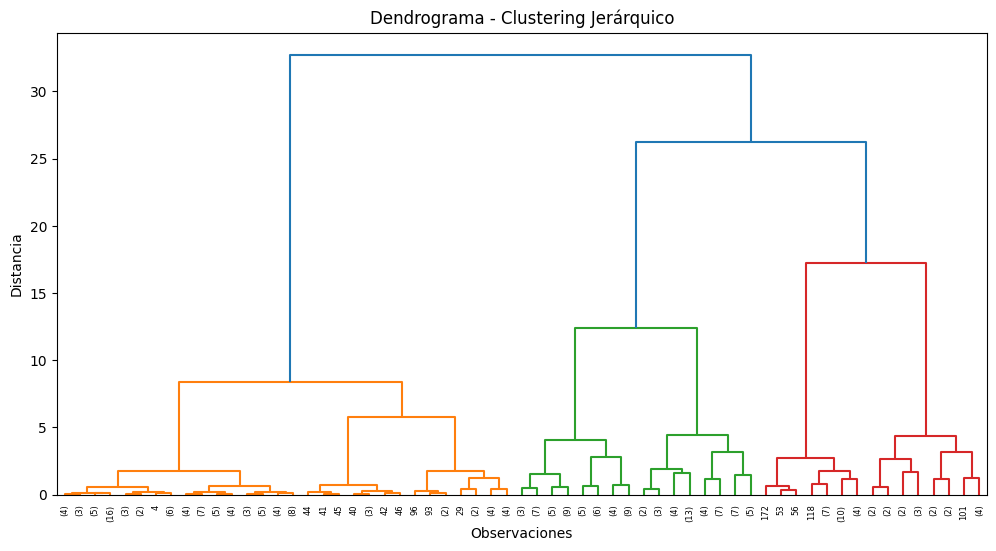

In [52]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Matriz linkage
Z = linkage(X_pca, method="ward")

# Dendrograma
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

In [53]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg = AgglomerativeClustering(n_clusters=6, linkage="ward")
labels_agg = agg.fit_predict(X_pca)

score_agg = silhouette_score(X_pca, labels_agg)

print("Silhouette Score Jerárquico:", round(score_agg,4))

Silhouette Score Jerárquico: 0.6263


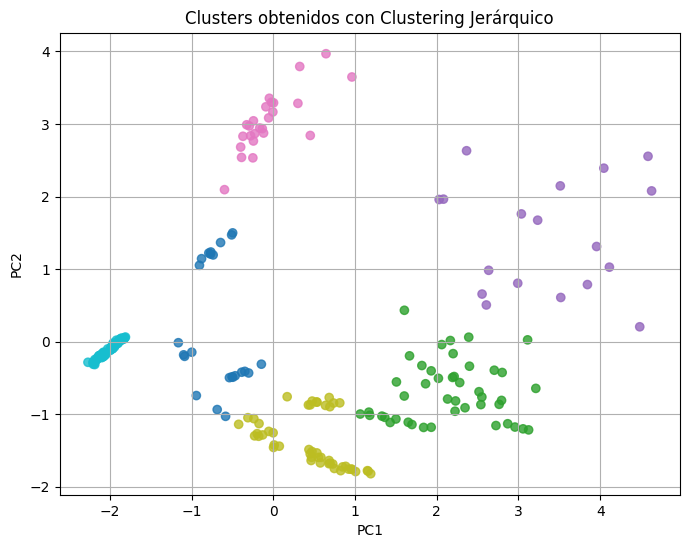

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg, cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters obtenidos con Clustering Jerárquico")
plt.grid(True)
plt.show()

Aplicando clustering jerárquico con enlace Ward y 6 clusters, se obtiene un Silhouette Score de **0.6263**.

El resultado es positivo y muestra una estructura razonable de grupos, aunque ligeramente inferior al obtenido con K-Means (**0.6493**).

Por tanto, ambos métodos funcionan correctamente sobre este conjunto de datos, aunque K-Means presenta un mejor rendimiento cuantitativo.

## 6. Clustering mediante DBSCAN

Finalmente, se aplicará DBSCAN, algoritmo basado en densidad que permite detectar grupos de forma arbitraria y también identificar posibles outliers.

A diferencia de K-Means y clustering jerárquico, DBSCAN requiere ajustar los hiperparámetros `eps` y `min_samples`, por lo que primero se prueban distintas combinaciones.

### 6.1 Ajuste de hiperparámetros de DBSCAN

Para aplicar DBSCAN es necesario seleccionar adecuadamente los hiperparámetros `eps` y `min_samples`.

Por ello, se prueban distintas combinaciones de valores, analizando el número de clusters generados, el número de observaciones clasificadas como ruido y el valor de Silhouette Score calculado sobre los puntos no considerados ruido.

In [55]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

resultados_dbscan = []

eps_values = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60]
min_samples_values = [3, 4, 5, 6, 8]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        ruido = list(labels).count(-1)

        if n_clusters >= 2:
            mask = labels != -1
            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_pca[mask], labels[mask])
            else:
                sil = None
        else:
            sil = None

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "ruido": ruido,
            "silhouette_sin_ruido": sil
        })

tabla_dbscan = pd.DataFrame(resultados_dbscan)
tabla_dbscan.sort_values("silhouette_sin_ruido", ascending=False).head(10)

,eps,min_samples,clusters,ruido,silhouette_sin_ruido
4,0.25,8,6,88,0.822229
3,0.25,6,8,69,0.801187
9,0.30,8,8,67,0.784723
2,0.25,5,11,44,0.746055
14,0.35,8,9,42,0.739660
8,0.30,6,10,41,0.736700
7,0.30,5,8,36,0.712949
12,0.35,5,8,33,0.704421
13,0.35,6,8,33,0.704421
1,0.25,4,13,35,0.702433


### 6.2 Modelo DBSCAN seleccionado

Tras analizar distintas combinaciones de hiperparámetros, se selecciona la configuración `eps=0.45` y `min_samples=5`, ya que permite obtener 6 clusters, coincidiendo con el número de clases astronómicas de referencia consideradas en el enunciado.

In [56]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.45, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

print("Clusters encontrados:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Ruido detectado:", list(labels_db).count(-1))

Clusters encontrados: 6
Ruido detectado: 30


Aplicando DBSCAN con `eps=0.45` y `min_samples=5`, el algoritmo detecta 6 clusters y clasifica 30 observaciones como ruido.

Esto indica que existen estrellas con características alejadas de los grupos principales, las cuales son identificadas como posibles outliers.

Aunque DBSCAN permite detectar ruido y grupos basados en densidad, su resultado es más sensible a la elección de hiperparámetros que K-Means o clustering jerárquico.

### 6.3 Visualización de DBSCAN

A continuación se representan los clusters obtenidos por DBSCAN en el espacio PCA.

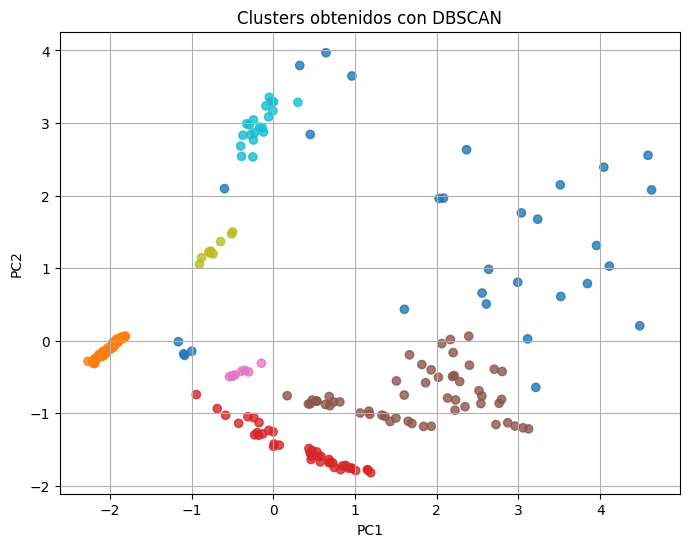

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters obtenidos con DBSCAN")
plt.grid(True)
plt.show()

### 6.4 Evaluación de DBSCAN mediante DBCV

Como indica el enunciado, para evaluar DBSCAN se utiliza la métrica DBCV, específica para clustering basado en densidad. Esta métrica permite valorar la calidad de los clusters considerando tanto la densidad interna como la separación entre grupos.

In [58]:
!pip install hdbscan -q

In [59]:
from hdbscan.validity import validity_index

dbcv_score = validity_index(X_pca.astype(float), labels_db)

print("DBCV DBSCAN:", round(dbcv_score, 4))

DBCV DBSCAN: 0.5582


El valor obtenido de DBCV para DBSCAN es de **0.5582**. Este resultado se utiliza para valorar la calidad del agrupamiento basado en densidad. Aunque DBSCAN consigue detectar 6 clusters, también clasifica 30 observaciones como ruido, por lo que su interpretación es menos directa que la de K-Means.

## 7. Comparación de algoritmos

Se han aplicado tres técnicas distintas de clustering sobre las dos componentes principales obtenidas mediante PCA:

- **K-Means**: obtiene el mejor resultado cuantitativo, con un Silhouette Score de **0.6493** y 6 clusters claramente diferenciados.
- **Clustering jerárquico**: presenta también buenos resultados, con Silhouette Score de **0.6263**, aunque ligeramente inferior.
- **DBSCAN**: detecta igualmente 6 grupos y obtiene un DBCV de **0.5582**, además de identificar 30 estrellas atípicas como ruido.

En conjunto, los tres métodos muestran una estructura interna clara en los datos, lo que refuerza la validez del análisis realizado.

In [60]:
tabla_resultados = pd.DataFrame({
    "Algoritmo": ["K-Means", "Jerárquico", "DBSCAN"],
    "Hiperparámetros": [
        "K=6",
        "n_clusters=6, linkage=ward",
        "eps=0.45, min_samples=5"
    ],
    "Métrica principal": [
        "Silhouette Score",
        "Silhouette Score",
        "DBCV"
    ],
    "Resultado": [
        "0.6493",
        "0.6263",
        round(dbcv_score, 4)
    ],
    "Observaciones": [
        "Mejor resultado global",
        "Buen resultado, ligeramente inferior a K-Means",
        "Detecta 6 clusters y 30 puntos de ruido"
    ]
})

tabla_resultados

,Algoritmo,Hiperparámetros,Métrica principal,Resultado,Observaciones
0,K-Means,K=6,Silhouette Score,0.6493,Mejor resultado global
1,Jerárquico,"n_clusters=6, linkage=ward",Silhouette Score,0.6263,"Buen resultado, ligeramente inferior a K-Means"
2,DBSCAN,"eps=0.45, min_samples=5",DBCV,0.5582,Detecta 6 clusters y 30 puntos de ruido


## 8. Pipeline recomendado

A partir de los resultados obtenidos, el pipeline recomendado sería:

1. Codificación ordinal de variables categóricas.
2. Escalado de variables mediante StandardScaler.
3. Reducción de dimensionalidad a 2 componentes mediante PCA.
4. Aplicación de **K-Means con K = 6**.

Este pipeline se recomienda por ofrecer el mejor rendimiento cuantitativo, una interpretación sencilla y clusters claramente diferenciados.

## 9. Comparación con las clases astronómicas

Para comparar los clusters obtenidos con las clases astronómicas del enunciado, se analiza el perfil medio de cada grupo generado por K-Means.

In [61]:
# Perfil de los clusters obtenidos con K-Means usando los datos originales
df_original = pd.read_csv(file_path)

df_perfil = df_original.copy()
df_perfil["cluster_kmeans"] = labels_kmeans

# Media de variables numéricas por cluster
perfil_numerico = df_perfil.groupby("cluster_kmeans")[["Temperature", "L", "R", "A_M"]].mean()

# Moda de variables categóricas por cluster
perfil_categorico = df_perfil.groupby("cluster_kmeans")[["Color", "Spectral_Class"]].agg(lambda x: x.mode()[0])

perfil_clusters = pd.concat([perfil_numerico, perfil_categorico], axis=1)

perfil_clusters

,Temperature,L,R,A_M,Color,Spectral_Class
cluster_kmeans,,,,,,
0,12608.901639,136.169234,1.274346,8.322934,Blue,B
1,3261.129412,0.017283,0.258887,14.593094,Red,M
2,3466.800000,206600.000000,129.500000,-6.798000,Red,M
3,24015.888889,512365.611111,1105.388889,-8.730667,Blue,O
4,3782.375000,245541.666667,1391.875000,-9.916250,Red,M
5,21793.357143,203221.857143,52.883976,-5.552738,Blue,O


El resultado obtenido con K-Means sugiere la existencia de 6 grupos principales, coincidiendo con las seis categorías de estrellas indicadas en el enunciado:

- Enana roja
- Enana marrón
- Enana blanca
- Secuencia principal
- Super gigante
- Hiper gigante

Se observa que los clusters separan estrellas con diferentes rangos de temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral. Esto permite relacionar algunos grupos con categorías astronómicas como enanas rojas, enanas blancas, estrellas de secuencia principal o estrellas gigantes.

Aunque los clusters obtenidos no tienen por qué coincidir exactamente con dichas clases, sí muestran patrones coherentes con la clasificación astronómica, ya que las estrellas con características físicas similares tienden a quedar agrupadas.

## 10. Conclusiones

En esta práctica se ha aplicado aprendizaje no supervisado para determinar posibles tipos de estrellas a partir de sus características físicas.

En primer lugar, se codificaron ordinalmente las variables categóricas `Color` y `Spectral_Class`, teniendo en cuenta su relación con la energía y la temperatura de las estrellas. Posteriormente, se escalaron los datos y se redujeron a dos dimensiones mediante PCA, conservando aproximadamente el 85.22% de la varianza total.

Sobre las dos componentes principales se aplicaron tres algoritmos de clustering: K-Means, clustering jerárquico y DBSCAN. K-Means obtuvo el mejor resultado cuantitativo con un Silhouette Score de 0.6493 para K=6. El clustering jerárquico también mostró un resultado positivo, con un Silhouette Score de 0.6263. Por su parte, DBSCAN detectó 6 clusters y 30 observaciones como ruido, aunque su interpretación es más sensible a la selección de hiperparámetros.

A partir de los resultados obtenidos, se recomienda como pipeline final: codificación ordinal, escalado con StandardScaler, reducción mediante PCA a 2 componentes y clustering con K-Means usando K=6.

Este resultado es coherente con la clasificación astronómica propuesta en el enunciado, ya que también se obtienen 6 grupos principales. Aunque los clusters no tienen por qué coincidir exactamente con las categorías reales, sí muestran una estructura similar y permiten identificar agrupaciones relevantes de estrellas sin utilizar etiquetas previas.